# Género, posición en cédula y probabilidad de victoria
# Elecciones municipales distritales, Perú 2006–2022

¿El efecto de la posición en la cédula de votación sobre la probabilidad
de ganar una alcaldía distrital varía según el sexo del candidato?

Se estima, para cada proceso electoral por separado:

$$P(\text{ganar}_i) = \beta_0 + \beta_1 \cdot \text{posición}_i + \beta_2 \cdot \text{mujer}_i + \beta_3 \cdot (\text{posición}_i \times \text{mujer}_i) + \gamma \cdot n\_candidatos_i + \varepsilon_i$$

**Fuentes:** JNE (candidatos), ONPE (resultados y posición en cédula).

**Estructura:**
1. Carga de datos y estadísticas generales
2. Análisis por año (2006 – 2022): descriptivas, gráfico y regresión
3. Comparación entre años

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.formula.api as smf
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11, 'font.family': 'serif',
    'axes.titlesize': 13, 'axes.labelsize': 11, 'legend.fontsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

BASE = os.path.dirname(os.path.abspath('__file__'))
if not os.path.exists(os.path.join(BASE, 'alcaldes_con_votos')):
    BASE = r'C:\Users\Usuario\Documents\GitHub\Forest_Peru\apellidos'

## 1. Carga de datos y panorama general

In [2]:
frames = []
for year in [2006, 2010, 2014, 2018, 2022]:
    path = os.path.join(BASE, 'alcaldes_con_votos', f'alcaldes_con_votos_{year}.csv')
    df = pd.read_csv(path, encoding='utf-8-sig')
    df.columns = [c.strip() for c in df.columns]
    df['año'] = year
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
data['posicion_cedula'] = pd.to_numeric(data['posicion_cedula'], errors='coerce')
data['total_votos'] = pd.to_numeric(data['total_votos'], errors='coerce')
data['ganador'] = pd.to_numeric(data['ganador'], errors='coerce')
data['mujer'] = (data['sexo'].str.strip().str.upper() == 'F').astype(int)
data['n_candidatos'] = data.groupby(['ubigeo', 'año'])['ganador'].transform('count')

print(f'Observaciones totales: {len(data):,}')
print(f'Con posición en cédula: {data["posicion_cedula"].notna().sum():,}')

Observaciones totales: 56,168
Con posición en cédula: 53,464


In [3]:
# Participación femenina por año
resumen = []
for year, g in data.groupby('año'):
    n = len(g)
    n_m = g['mujer'].sum()
    n_gan = int(g['ganador'].sum())
    n_gan_m = g[(g['ganador']==1) & (g['mujer']==1)].shape[0]
    resumen.append({
        'Año': year, 'Candidatos': n, 'Mujeres': n_m,
        '% Candidatas': round(n_m/n*100, 1),
        'Alcaldesas': n_gan_m,
        '% Alcaldesas': round(n_gan_m/n_gan*100, 1) if n_gan else 0,
        'Distritos': g['ubigeo'].nunique(),
    })
tabla_gen = pd.DataFrame(resumen)
print(tabla_gen.to_string(index=False))

 Año  Candidatos  Mujeres  % Candidatas  Alcaldesas  % Alcaldesas  Distritos
2006       11155      674           6.0          54           3.3       1636
2010       11419      792           6.9          70           4.3       1638
2014       11535      883           7.7          58           3.5       1647
2018       12160     1071           8.8          80           4.8       1678
2022        9899      974           9.8          88           5.2       1691


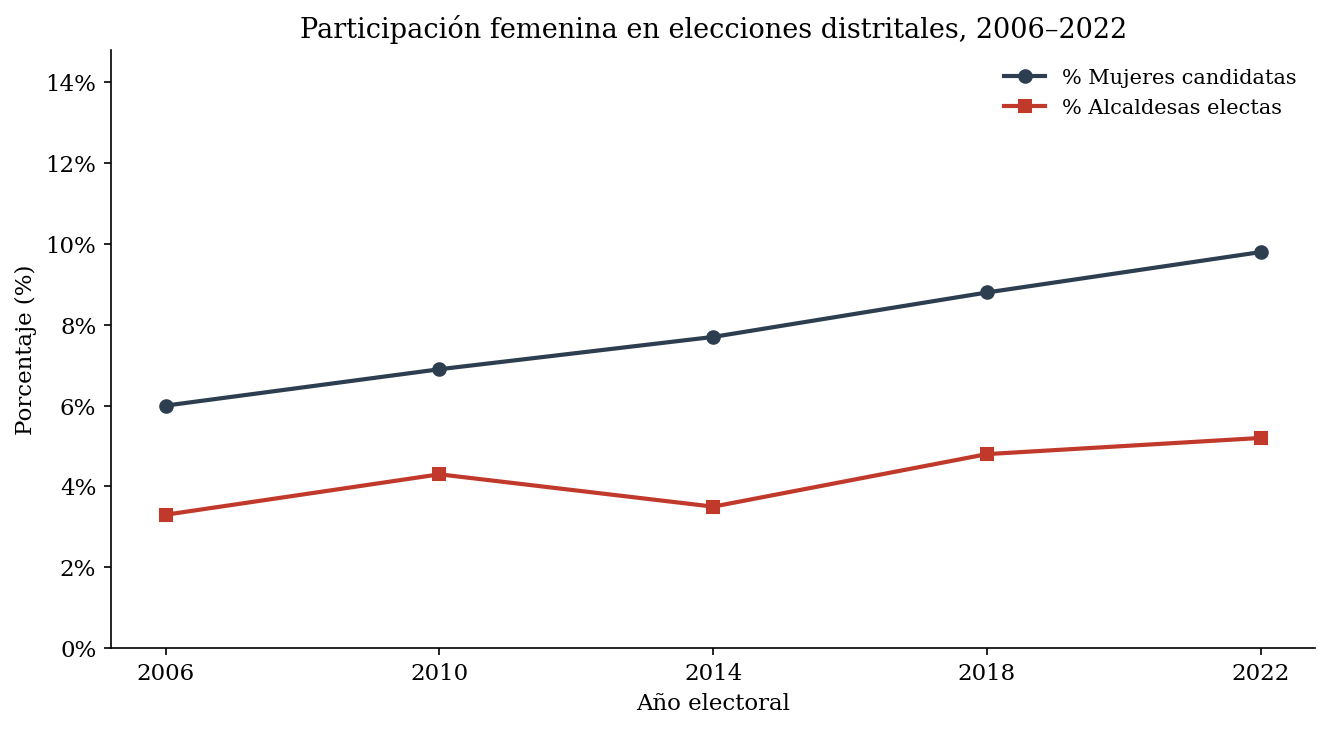

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tabla_gen['Año'], tabla_gen['% Candidatas'], 'o-',
        color='#2c3e50', lw=2, label='% Mujeres candidatas')
ax.plot(tabla_gen['Año'], tabla_gen['% Alcaldesas'], 's-',
        color='#c0392b', lw=2, label='% Alcaldesas electas')
ax.set_xlabel('Año electoral')
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Participación femenina en elecciones distritales, 2006–2022')
ax.legend(frameon=False)
ax.set_xticks([2006, 2010, 2014, 2018, 2022])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_ylim(0, tabla_gen['% Candidatas'].max() + 5)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_participacion_femenina.png'), dpi=300, bbox_inches='tight')
plt.show()

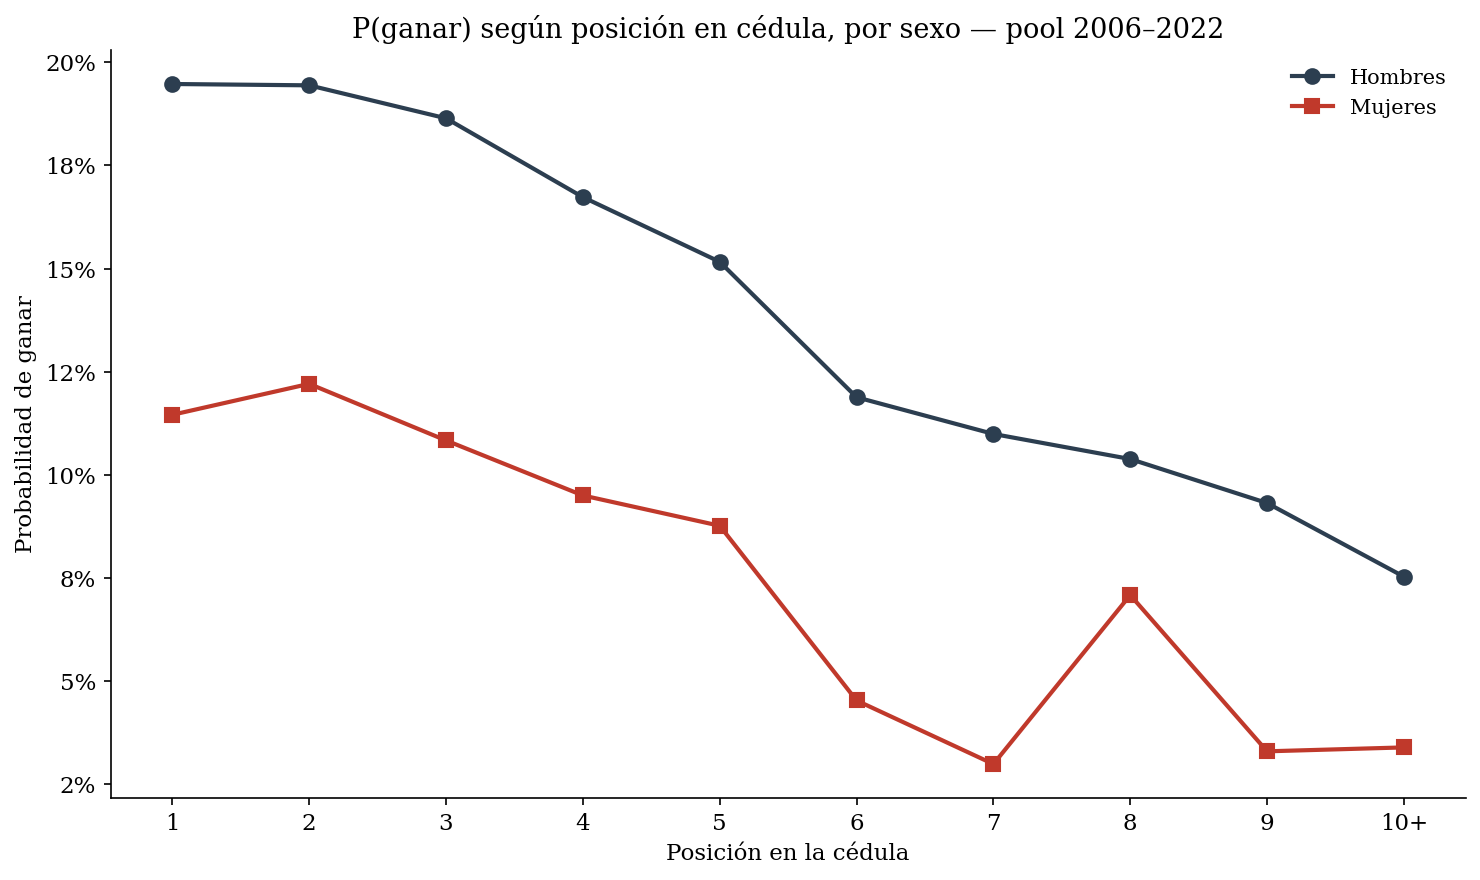

In [5]:
# P(ganar) por posición y sexo — pool de todos los años
dp = data.dropna(subset=['posicion_cedula', 'ganador']).copy()
dp['pos_grupo'] = dp['posicion_cedula'].clip(upper=10).astype(int)

fig, ax = plt.subplots(figsize=(10, 6))
for sexo, color, marker, lab in [(0,'#2c3e50','o','Hombres'),(1,'#c0392b','s','Mujeres')]:
    sub = dp[dp['mujer']==sexo].groupby('pos_grupo')['ganador'].mean()
    ax.plot(sub.index, sub.values, marker=marker, color=color, lw=2, ms=7, label=lab)
ax.set_xlabel('Posición en la cédula')
ax.set_ylabel('Probabilidad de ganar')
ax.set_title('P(ganar) según posición en cédula, por sexo — pool 2006–2022')
ax.legend(frameon=False)
ax.set_xticks(range(1,11))
ax.set_xticklabels([str(i) for i in range(1,10)]+['10+'])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_posicion_x_genero.png'), dpi=300, bbox_inches='tight')
plt.show()

---

A continuación se analiza cada proceso electoral por separado.
Para cada año se reporta:
- Tabla descriptiva (candidatos, mujeres, tasa de victoria por sexo)
- Gráfico de P(ganar) por posición y sexo
- MPL: $ganador = \beta_1 pos + \beta_2 mujer + \beta_3 (pos \times mujer) + \gamma\, n\_cand + \varepsilon$

Se utiliza una función auxiliar para evitar repetir código.

In [6]:
def analisis_anual(data_año, year):
    """Análisis completo para un año electoral."""
    da = data_año.copy()
    n = len(da)
    n_pos = da['posicion_cedula'].notna().sum()
    n_m = da['mujer'].sum()
    n_h = n - n_m
    gan = int(da['ganador'].sum())
    gan_m = da[(da['ganador']==1)&(da['mujer']==1)].shape[0]
    gan_h = gan - gan_m
    
    print(f'Candidatos: {n:,}  (H={n_h:,}  M={n_m:,})  '
          f'Distritos: {da["ubigeo"].nunique():,}')
    print(f'Con posición en cédula: {n_pos:,} ({n_pos/n*100:.1f}%)')
    print(f'Mujeres candidatas: {n_m/n*100:.1f}%')
    print(f'Tasa de victoria — Hombres: {gan_h/n_h*100:.2f}%  '
          f'Mujeres: {gan_m/n_m*100:.2f}%' if n_m > 0 else '')
    print(f'Alcaldesas electas: {gan_m}/{gan} ({gan_m/gan*100:.1f}%)')
    
    # --- Gráfico ---
    dv = da.dropna(subset=['posicion_cedula','ganador']).copy()
    dv['pos_grupo'] = dv['posicion_cedula'].clip(upper=10).astype(int)
    
    fig, ax = plt.subplots(figsize=(9, 5))
    for sexo, color, marker, lab in [(0,'#2c3e50','o','Hombres'),(1,'#c0392b','s','Mujeres')]:
        sub = dv[dv['mujer']==sexo].groupby('pos_grupo')['ganador'].agg(['mean','count'])
        # Solo graficar posiciones con al menos 10 observaciones
        sub = sub[sub['count'] >= 10]
        ax.plot(sub.index, sub['mean'], marker=marker, color=color,
                lw=2, ms=6, label=lab)
    ax.set_xlabel('Posición en la cédula')
    ax.set_ylabel('P(ganar)')
    ax.set_title(f'P(ganar) según posición en cédula, por sexo — {year}')
    ax.legend(frameon=False)
    ax.set_xticks(range(1,11))
    ax.set_xticklabels([str(i) for i in range(1,10)]+['10+'])
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    plt.tight_layout()
    plt.savefig(os.path.join(BASE, f'fig_posicion_x_genero_{year}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # --- Regresión MPL ---
    reg = dv[['ganador','posicion_cedula','mujer','n_candidatos']].dropna()
    if len(reg) < 50:
        print('Muestra insuficiente para regresión.')
        return None
    
    mod = smf.ols('ganador ~ posicion_cedula * mujer + n_candidatos',
                  data=reg).fit(cov_type='HC1')
    
    vars_show = ['Intercept','posicion_cedula','mujer',
                 'posicion_cedula:mujer','n_candidatos']
    print(f'\nMPL — N = {int(mod.nobs):,}   R² = {mod.rsquared:.4f}')
    print(f'{"Variable":<28} {"Coef":>9} {"SE":>9} {"t":>7} {"p":>7}')
    print('-'*62)
    for v in vars_show:
        if v in mod.params.index:
            sig = '***' if mod.pvalues[v]<0.01 else '**' if mod.pvalues[v]<0.05 \
                  else '*' if mod.pvalues[v]<0.1 else ''
            print(f'{v:<28} {mod.params[v]:>9.5f} {mod.bse[v]:>9.5f} '
                  f'{mod.tvalues[v]:>7.2f} {mod.pvalues[v]:>7.4f} {sig}')
    
    b_pos = mod.params['posicion_cedula']
    b_int = mod.params.get('posicion_cedula:mujer', 0)
    print(f'\nEfecto posición (hombres): {b_pos*100:+.3f} pp')
    print(f'Efecto posición (mujeres): {(b_pos+b_int)*100:+.3f} pp')
    
    return mod

## 2. Elecciones municipales 2006

Candidatos: 11,155  (H=10,481  M=674)  Distritos: 1,636
Con posición en cédula: 11,059 (99.1%)
Mujeres candidatas: 6.0%
Tasa de victoria — Hombres: 15.09%  Mujeres: 8.01%
Alcaldesas electas: 54/1636 (3.3%)


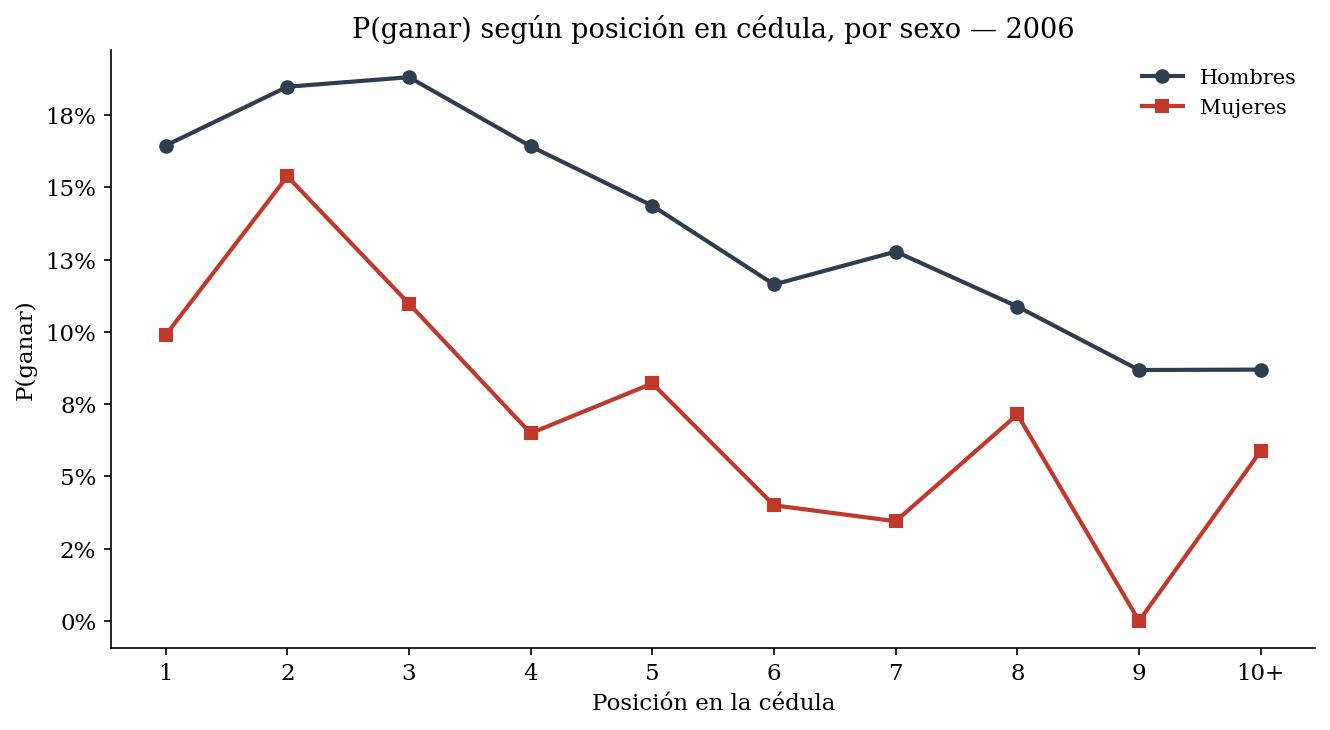


MPL — N = 11,059   R² = 0.0232
Variable                          Coef        SE       t       p
--------------------------------------------------------------
Intercept                      0.29338   0.01059   27.70  0.0000 ***
posicion_cedula               -0.00190   0.00129   -1.48  0.1395 
mujer                         -0.06355   0.02280   -2.79  0.0053 ***
posicion_cedula:mujer          0.00114   0.00353    0.32  0.7459 
n_candidatos                  -0.01713   0.00128  -13.42  0.0000 ***

Efecto posición (hombres): -0.190 pp
Efecto posición (mujeres): -0.075 pp


In [7]:
mod_2006 = analisis_anual(data[data['año']==2006], 2006)

## 3. Elecciones municipales 2010

Candidatos: 11,419  (H=10,627  M=792)  Distritos: 1,638
Con posición en cédula: 11,137 (97.5%)
Mujeres candidatas: 6.9%
Tasa de victoria — Hombres: 14.75%  Mujeres: 8.84%
Alcaldesas electas: 70/1638 (4.3%)


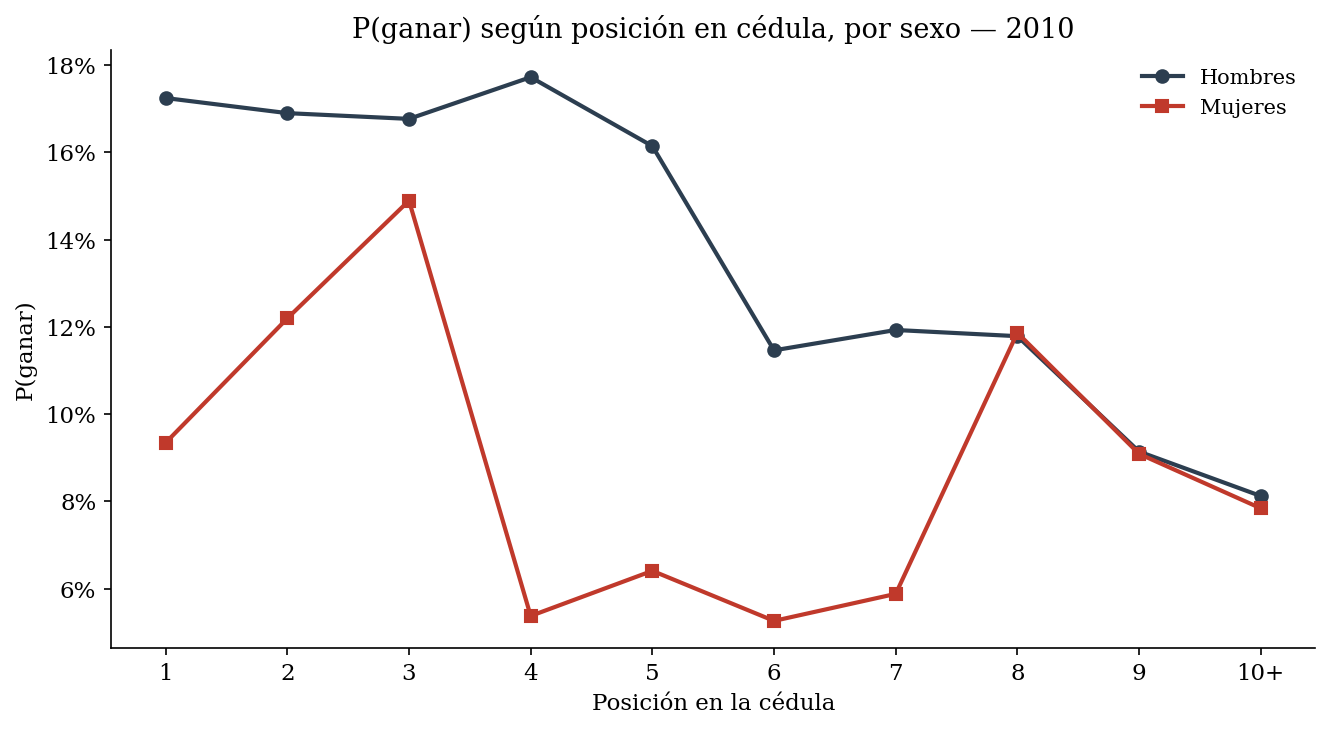


MPL — N = 11,137   R² = 0.0226
Variable                          Coef        SE       t       p
--------------------------------------------------------------
Intercept                      0.29611   0.01088   27.21  0.0000 ***
posicion_cedula               -0.00078   0.00131   -0.60  0.5501 
mujer                         -0.08504   0.02209   -3.85  0.0001 ***
posicion_cedula:mujer          0.00746   0.00401    1.86  0.0630 *
n_candidatos                  -0.01785   0.00128  -13.91  0.0000 ***

Efecto posición (hombres): -0.078 pp
Efecto posición (mujeres): +0.667 pp


In [8]:
mod_2010 = analisis_anual(data[data['año']==2010], 2010)

## 4. Elecciones municipales 2014

Candidatos: 11,535  (H=10,652  M=883)  Distritos: 1,647
Con posición en cédula: 11,455 (99.3%)
Mujeres candidatas: 7.7%
Tasa de victoria — Hombres: 14.92%  Mujeres: 6.57%
Alcaldesas electas: 58/1647 (3.5%)


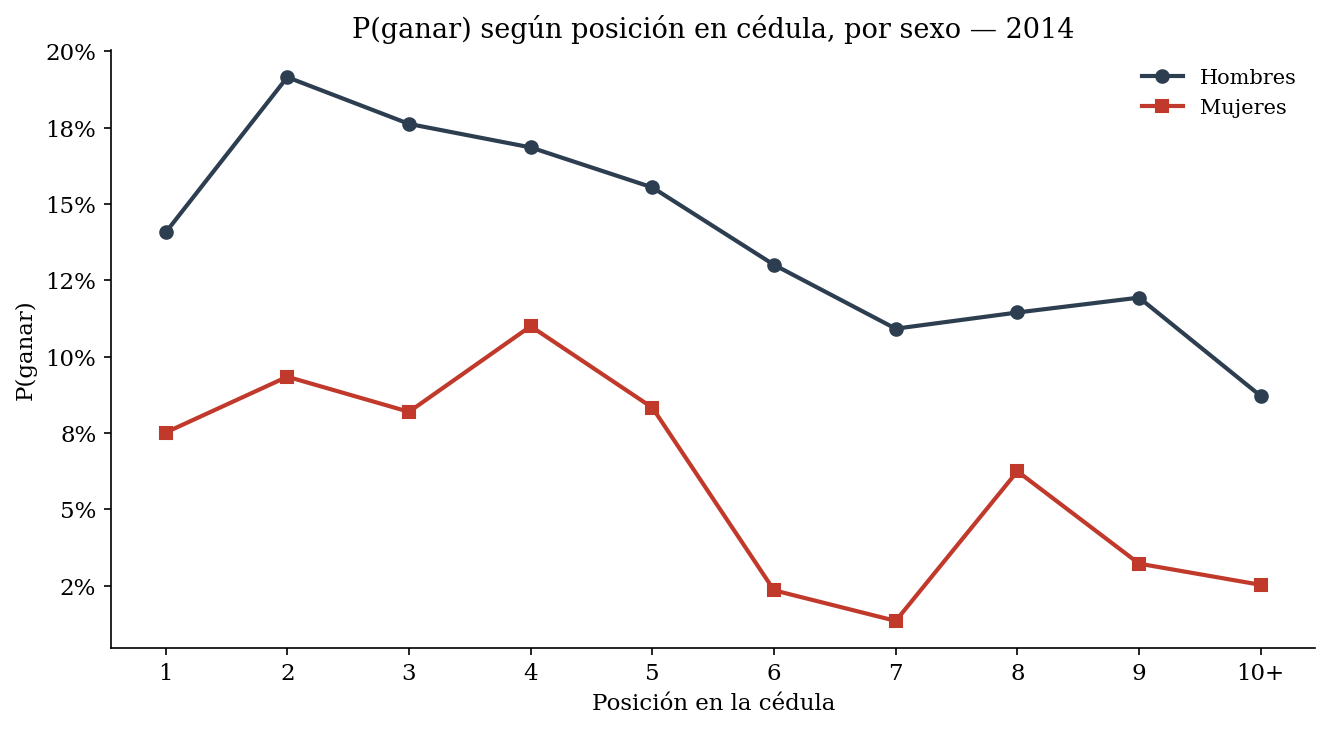


MPL — N = 11,455   R² = 0.0257
Variable                          Coef        SE       t       p
--------------------------------------------------------------
Intercept                      0.28208   0.00983   28.68  0.0000 ***
posicion_cedula                0.00158   0.00121    1.31  0.1903 
mujer                         -0.08089   0.01734   -4.67  0.0000 ***
posicion_cedula:mujer          0.00113   0.00257    0.44  0.6601 
n_candidatos                  -0.01723   0.00111  -15.57  0.0000 ***

Efecto posición (hombres): +0.158 pp
Efecto posición (mujeres): +0.271 pp


In [9]:
mod_2014 = analisis_anual(data[data['año']==2014], 2014)

## 5. Elecciones municipales 2018

Candidatos: 12,160  (H=11,089  M=1,071)  Distritos: 1,678
Con posición en cédula: 10,831 (89.1%)
Mujeres candidatas: 8.8%
Tasa de victoria — Hombres: 14.41%  Mujeres: 7.47%
Alcaldesas electas: 80/1678 (4.8%)


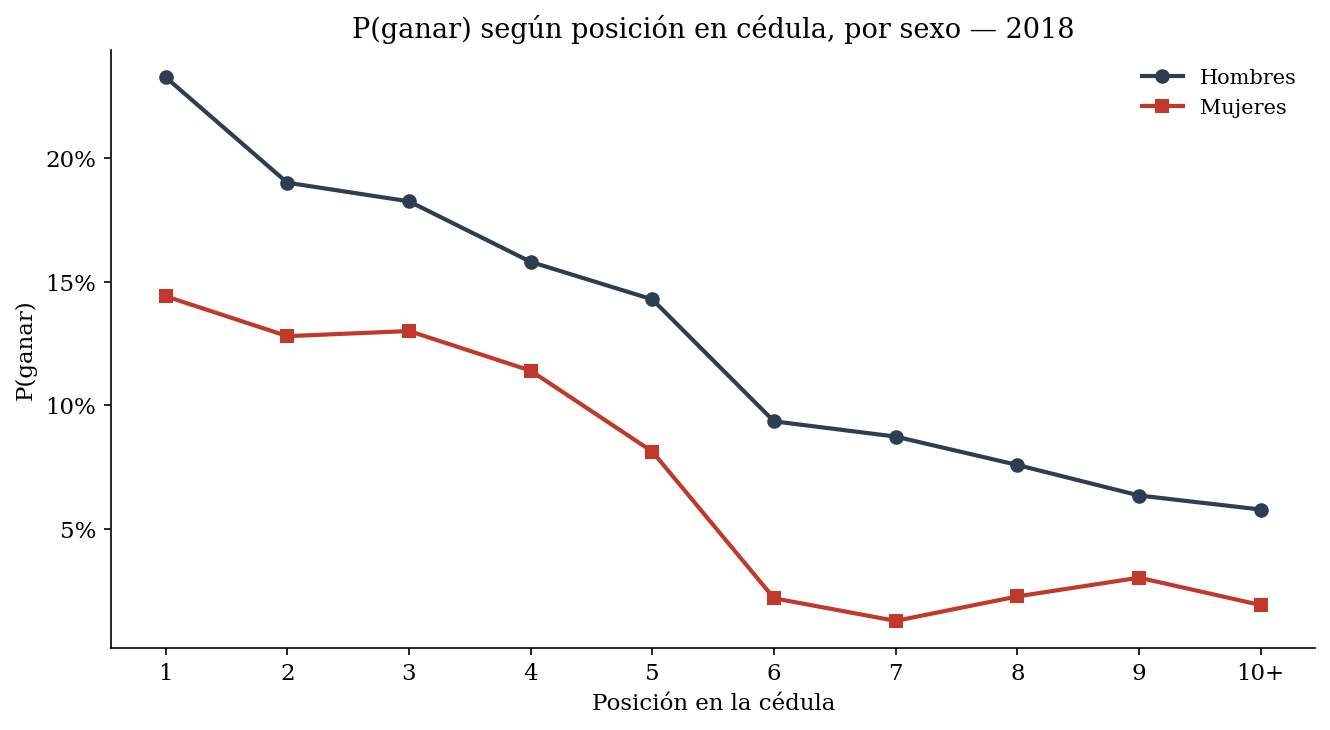


MPL — N = 10,831   R² = 0.0305
Variable                          Coef        SE       t       p
--------------------------------------------------------------
Intercept                      0.27763   0.00884   31.41  0.0000 ***
posicion_cedula               -0.00989   0.00125   -7.90  0.0000 ***
mujer                         -0.07743   0.02011   -3.85  0.0001 ***
posicion_cedula:mujer          0.00510   0.00286    1.78  0.0749 *
n_candidatos                  -0.00952   0.00093  -10.19  0.0000 ***

Efecto posición (hombres): -0.989 pp
Efecto posición (mujeres): -0.480 pp


In [10]:
mod_2018 = analisis_anual(data[data['año']==2018], 2018)

## 6. Elecciones municipales 2022

Candidatos: 9,899  (H=8,925  M=974)  Distritos: 1,691
Con posición en cédula: 8,982 (90.7%)
Mujeres candidatas: 9.8%
Tasa de victoria — Hombres: 17.96%  Mujeres: 9.03%
Alcaldesas electas: 88/1691 (5.2%)


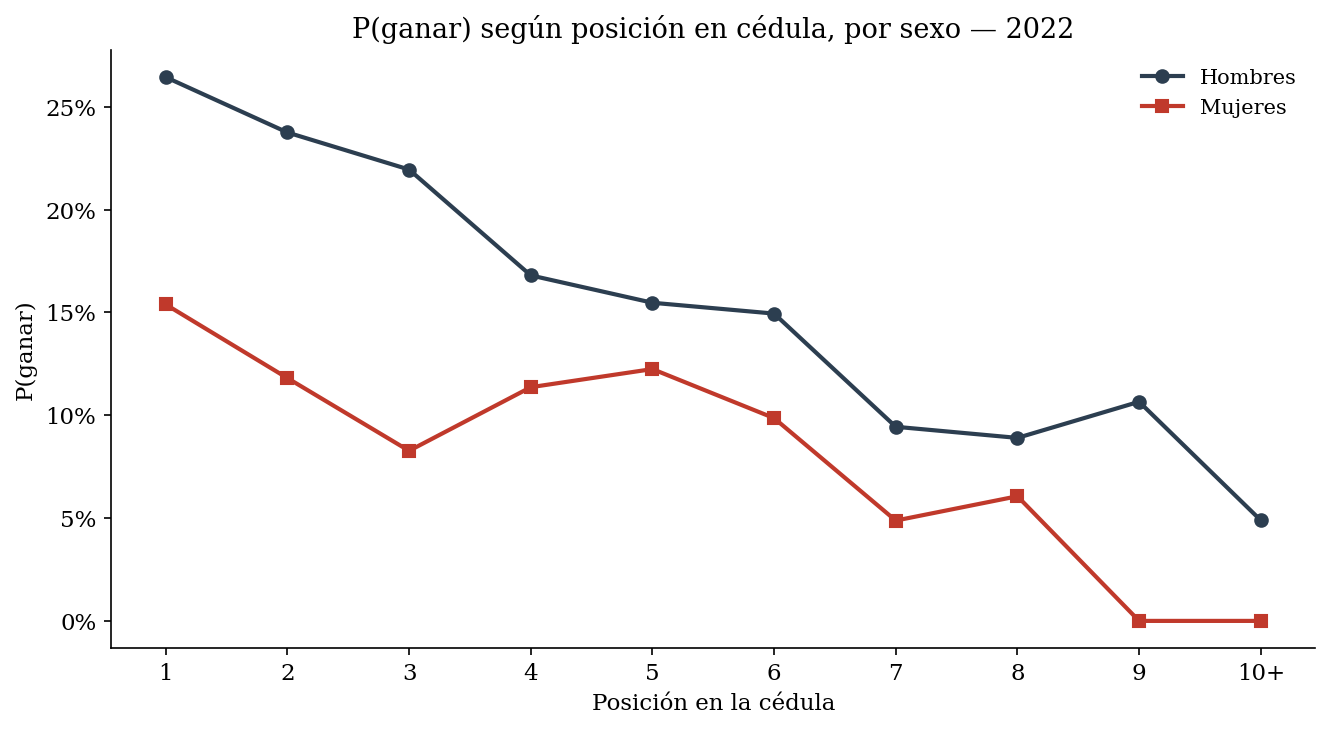


MPL — N = 8,982   R² = 0.0362
Variable                          Coef        SE       t       p
--------------------------------------------------------------
Intercept                      0.35892   0.01116   32.17  0.0000 ***
posicion_cedula               -0.01238   0.00190   -6.52  0.0000 ***
mujer                         -0.11674   0.02057   -5.67  0.0000 ***
posicion_cedula:mujer          0.01087   0.00344    3.16  0.0016 ***
n_candidatos                  -0.01726   0.00153  -11.31  0.0000 ***

Efecto posición (hombres): -1.238 pp
Efecto posición (mujeres): -0.151 pp


In [11]:
mod_2022 = analisis_anual(data[data['año']==2022], 2022)

## 7. Comparación entre años

Tabla resumen de los coeficientes clave de cada regresión anual.

In [12]:
# Tabla de coeficientes por año
modelos = {'2006': mod_2006, '2010': mod_2010, '2014': mod_2014,
           '2018': mod_2018, '2022': mod_2022}

filas = []
for year, mod in modelos.items():
    if mod is None:
        continue
    b_pos = mod.params['posicion_cedula']
    p_pos = mod.pvalues['posicion_cedula']
    b_muj = mod.params['mujer']
    p_muj = mod.pvalues['mujer']
    b_int = mod.params.get('posicion_cedula:mujer', np.nan)
    p_int = mod.pvalues.get('posicion_cedula:mujer', np.nan)
    filas.append({
        'Año': year,
        'N': int(mod.nobs),
        'R²': round(mod.rsquared, 4),
        'β_pos (pp)': round(b_pos*100, 3),
        'p_pos': round(p_pos, 4),
        'β_mujer (pp)': round(b_muj*100, 2),
        'p_mujer': round(p_muj, 4),
        'β_interacción (pp)': round(b_int*100, 3) if not np.isnan(b_int) else np.nan,
        'p_interacción': round(p_int, 4) if not np.isnan(p_int) else np.nan,
    })

comp = pd.DataFrame(filas)
print('Coeficientes MPL por año (efecto en puntos porcentuales):')
print(comp.to_string(index=False))

Coeficientes MPL por año (efecto en puntos porcentuales):
 Año     N     R²  β_pos (pp)  p_pos  β_mujer (pp)  p_mujer  β_interacción (pp)  p_interacción
2006 11059 0.0232      -0.190 0.1395         -6.35   0.0053               0.114         0.7459
2010 11137 0.0226      -0.078 0.5501         -8.50   0.0001               0.746         0.0630
2014 11455 0.0257       0.158 0.1903         -8.09   0.0000               0.113         0.6601
2018 10831 0.0305      -0.989 0.0000         -7.74   0.0001               0.510         0.0749
2022  8982 0.0362      -1.238 0.0000        -11.67   0.0000               1.087         0.0016


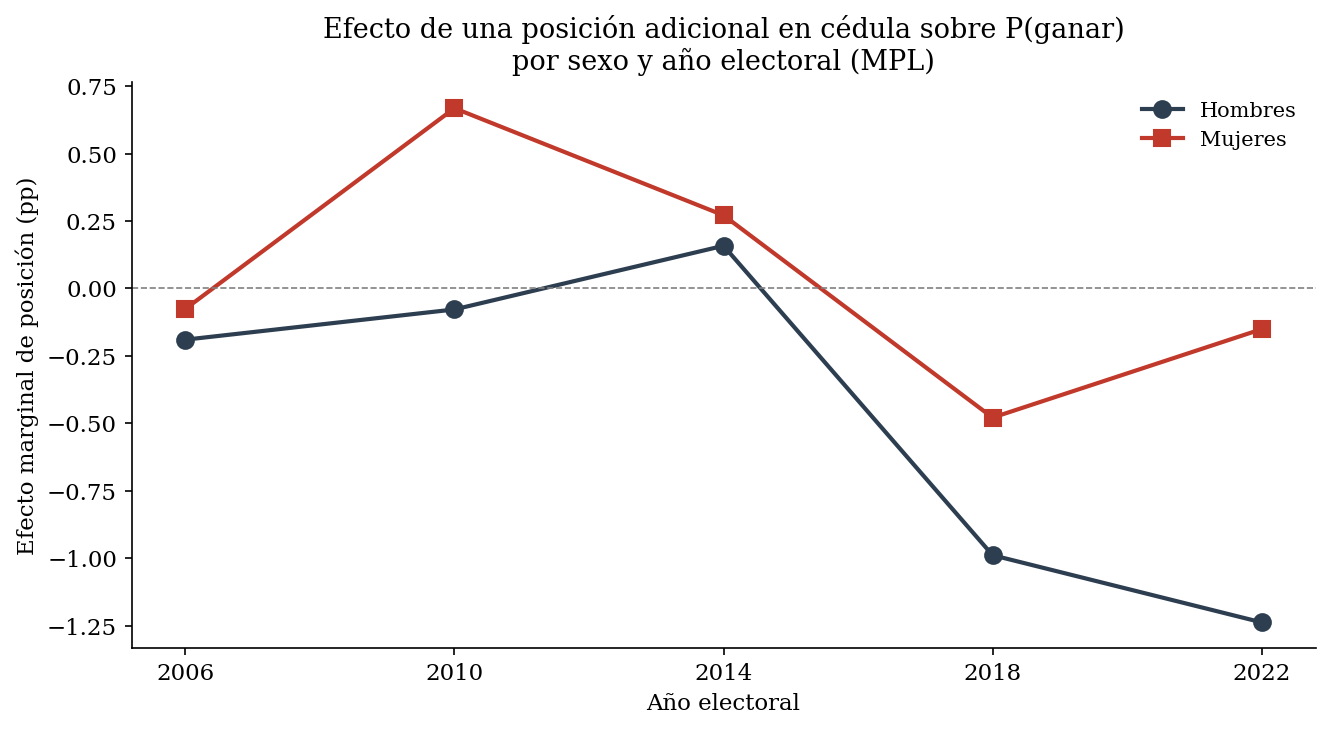

In [13]:
# Gráfico: coeficiente de posición por año, hombres vs mujeres
fig, ax = plt.subplots(figsize=(9, 5))

años = [int(r['Año']) for r in filas]
ef_h = [r['β_pos (pp)'] for r in filas]
ef_m = [r['β_pos (pp)'] + r['β_interacción (pp)'] for r in filas]

ax.plot(años, ef_h, 'o-', color='#2c3e50', lw=2, ms=8, label='Hombres')
ax.plot(años, ef_m, 's-', color='#c0392b', lw=2, ms=8, label='Mujeres')
ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.set_xlabel('Año electoral')
ax.set_ylabel('Efecto marginal de posición (pp)')
ax.set_title('Efecto de una posición adicional en cédula sobre P(ganar)\n'
             'por sexo y año electoral (MPL)')
ax.legend(frameon=False)
ax.set_xticks(años)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_efecto_posicion_por_año_genero.png'),
            dpi=300, bbox_inches='tight')
plt.show()

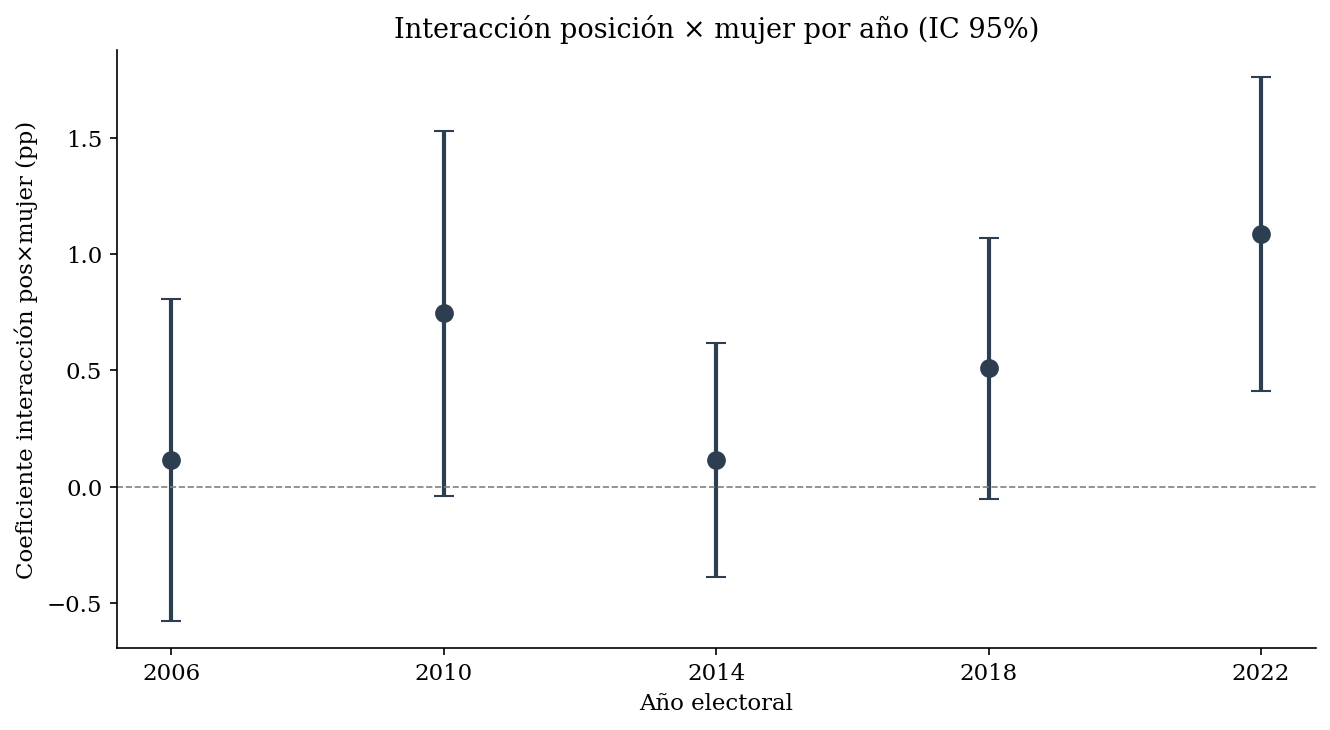

In [14]:
# Gráfico: coeficiente de interacción pos×mujer con IC 95%
fig, ax = plt.subplots(figsize=(9, 5))

coefs, cis_lo, cis_hi, xs = [], [], [], []
for year, mod in modelos.items():
    if mod is None or 'posicion_cedula:mujer' not in mod.params.index:
        continue
    b = mod.params['posicion_cedula:mujer'] * 100
    se = mod.bse['posicion_cedula:mujer'] * 100
    coefs.append(b)
    cis_lo.append(b - 1.96*se)
    cis_hi.append(b + 1.96*se)
    xs.append(int(year))

ax.errorbar(xs, coefs, yerr=[np.array(coefs)-np.array(cis_lo),
            np.array(cis_hi)-np.array(coefs)],
            fmt='o', color='#2c3e50', capsize=5, ms=8, lw=2)
ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.set_xlabel('Año electoral')
ax.set_ylabel('Coeficiente interacción pos×mujer (pp)')
ax.set_title('Interacción posición × mujer por año (IC 95%)')
ax.set_xticks(xs)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_interaccion_genero_IC.png'),
            dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Modelo pooled con EF de año y departamento (referencia)
dp_all = data.dropna(subset=['posicion_cedula','ganador']).copy()
dp_all['año_str'] = dp_all['año'].astype(str)

mod_pool = smf.ols(
    'ganador ~ posicion_cedula * mujer + n_candidatos + C(año_str) + C(departamento)',
    data=dp_all
).fit(cov_type='HC1')

print('Modelo pooled con EF año + EF departamento (referencia):')
print(f'N = {int(mod_pool.nobs):,}   R² = {mod_pool.rsquared:.4f}')
for v in ['posicion_cedula','mujer','posicion_cedula:mujer','n_candidatos']:
    sig = '***' if mod_pool.pvalues[v]<0.01 else '**' if mod_pool.pvalues[v]<0.05 \
          else '*' if mod_pool.pvalues[v]<0.1 else ''
    print(f'  {v:<28} {mod_pool.params[v]*100:>+8.3f} pp  (p={mod_pool.pvalues[v]:.4f}) {sig}')

Modelo pooled con EF año + EF departamento (referencia):
N = 53,464   R² = 0.0286
  posicion_cedula                -0.391 pp  (p=0.0000) ***
  mujer                          -8.398 pp  (p=0.0000) ***
  posicion_cedula:mujer          +0.430 pp  (p=0.0027) ***
  n_candidatos                   -1.541 pp  (p=0.0000) ***
